# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report

/content/proj
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.2 MB/s eta 0:00:00
  Building editable for international-airpassengers-project (pyproject.toml) ... done


/content/proj/coursekit/plotting.py:599: SyntaxWarning: invalid escape sequence '\h'
  :math:`\hat{F}` whose characteristics do not change over time -- so that a
/content/proj/coursekit/plotting.py:676: SyntaxWarning: invalid escape sequence '\h'
  """Draw the h-step errors :math:`e_{t+h|t} = y_{t+h} - \hat{y}_{t+h|t}`.


---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# TODO: confirm the calendar. How many months, what range, any gaps?
#       (Same three checks you ran on the spine on Day 1.)

n_obs = len(df)

range_ = (df["ds"].min(), df["ds"].max())

n_gaps = int((df["ds"].diff().dt.days > 32).sum())

print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")

144 months, 1949-01-01 to 1960-12-01, 0 gaps


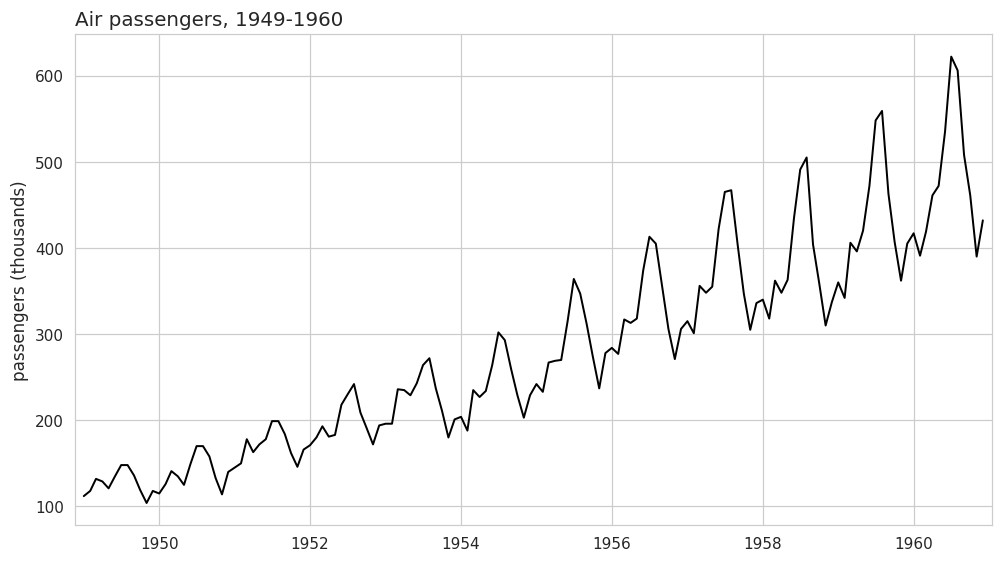

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Before any model, write two sentences that describe this
series in plain language - the kind a non-forecaster could repeat. (Trend?
Seasonality? What happens to the swings as the level grows? Cycle?) These two
sentences belong at the top of your report.

---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

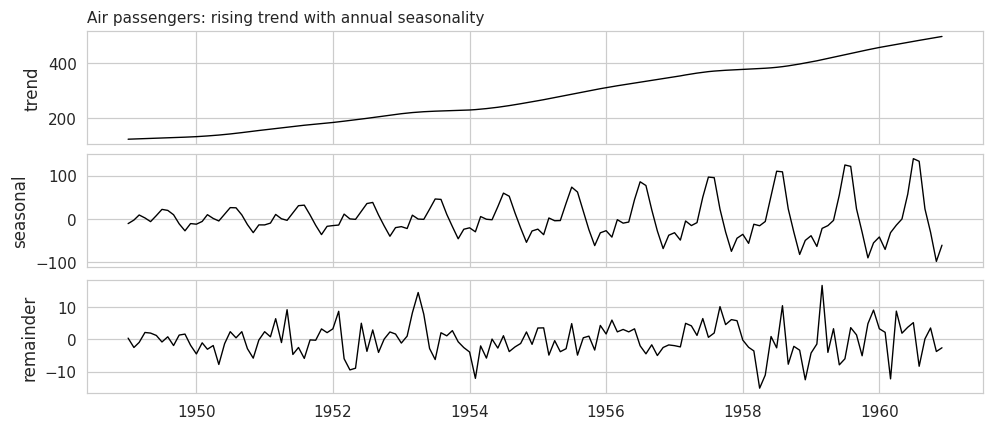

In [5]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["y"], period=SEASON_LENGTH)
result = stl.fit()

dcmp = pd.DataFrame({
    "ds": df["ds"],
    "trend": result.trend,
    "seasonal": result.seasonal,
    "remainder": result.resid
})

P.decomposition_plot(
    dcmp,
    cols=["trend", "seasonal", "remainder"],
    title="Air passengers: rising trend with annual seasonality",
    x="ds"
)

plt.show()

**Interpretation:** The STL decomposition shows that the series is driven by a strong upward trend and a clear annual seasonal pattern. The seasonal fluctuations become larger over time, while the remainder is mostly centered around zero with some larger unexplained variations toward the end of the series.

**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [6]:
trend_strength = max(
    0,
    1 - dcmp["remainder"].var()
    / (dcmp["trend"] + dcmp["remainder"]).var()
)

seasonal_strength = max(
    0,
    1 - dcmp["remainder"].var()
    / (dcmp["seasonal"] + dcmp["remainder"]).var()
)

print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")

trend strength: 1.00
seasonal strength: 0.99


**Interpretation:** The trend strength is 1.00 and the seasonal strength is 0.99, indicating that both components are extremely strong. This supports using forecasting models that explicitly account for trend and annual seasonality rather than models that ignore these structures.

**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

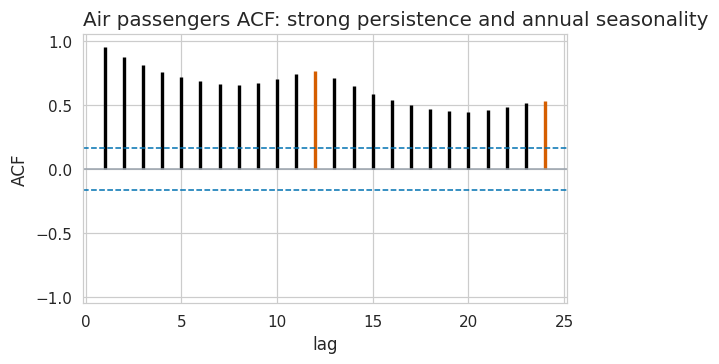

In [7]:
P.acf_plot(
    df["y"],
    nlags=24,
    highlight_every=12,
    title="Air passengers ACF: strong persistence and annual seasonality"
)

plt.show()

**Interpretation:** The ACF remains strongly positive across many lags and decays slowly, which indicates strong persistence and trend. The autocorrelation is approximately 0.76 at lag 12 and 0.53 at lag 24, confirming a strong annual seasonal pattern that persists across multiple years. Therefore, the forecasting model should account for both trend and annual seasonality.

---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [8]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS",
    n_jobs=1
)

floor_fc = floor_sf.forecast(
    df=df,
    h=H_REPORT,
    level=scoring.LEVELS
)

floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


**Interpretation:** The Ljung-Box p-values at lags 12 and 24 are extremely small, so the Seasonal Naive residuals are not white noise. This means the benchmark leaves significant serial structure unexplained, likely related to the continuing trend and changing seasonal magnitude. A model such as ARIMA or ETS may be able to capture part of this remaining structure.

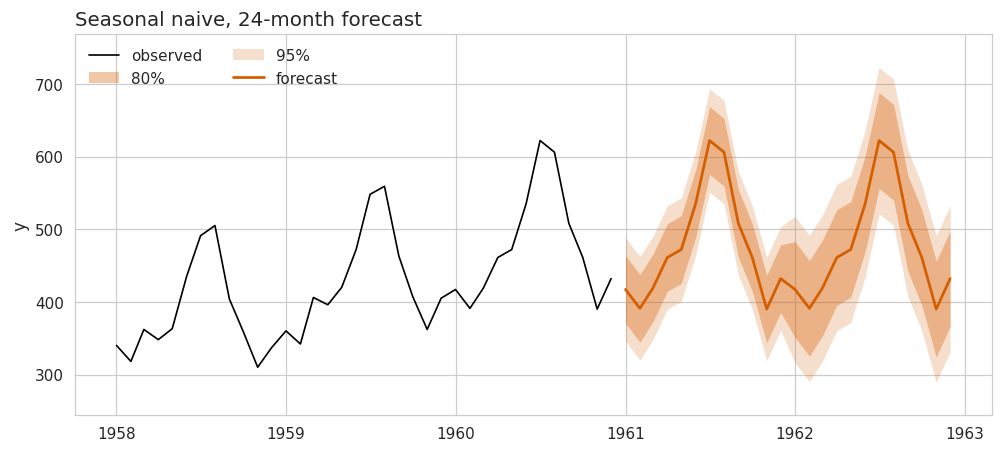

In [9]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

In [23]:
from statsforecast.models import Naive

benchmark_sf = StatsForecast(
    models=[Naive()],
    freq="MS",
    n_jobs=1
)

benchmark_fc = benchmark_sf.forecast(
    df=df,
    h=H_REPORT,
    level=scoring.LEVELS
)

benchmark_fc.head()

,unique_id,ds,Naive,Naive-lo-20,Naive-lo-40,Naive-lo-60,Naive-lo-80,Naive-lo-95,Naive-hi-20,Naive-hi-40,Naive-hi-60,Naive-hi-80,Naive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,432.0,423.459566,414.322245,403.628605,388.798374,365.928814,440.540434,449.677755,460.371395,475.201626,498.071186
1,Air passengers (Box & Jenkins),1961-02-01,432.0,419.922002,406.999879,391.876788,370.903674,338.561233,444.077998,457.000121,472.123212,493.096326,525.438767
2,Air passengers (Box & Jenkins),1961-03-01,432.0,417.207534,401.381230,382.859302,357.172589,317.561350,446.792466,462.618770,481.140698,506.827411,546.438650
3,Air passengers (Box & Jenkins),1961-04-01,432.0,414.919132,396.644490,375.257210,345.596748,299.857629,449.080868,467.355510,488.742790,518.403252,564.142371
4,Air passengers (Box & Jenkins),1961-05-01,432.0,412.903009,392.471338,368.559632,335.398227,284.260338,451.096991,471.528662,495.440368,528.601773,579.739662


In [24]:
naive_cv_sf = StatsForecast(
    models=[Naive()],
    freq="MS",
    n_jobs=1
)

naive_cv = naive_cv_sf.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS
)

naive_results = scoring.score_cv(
    naive_cv,
    "Naive",
    df
)

print(naive_results)

{'mase': 2.118736399903194, 'rmsse': 2.4522331140693323, 'crps': 0.11032495202589376, 'coverage_80': 0.6875, 'mase_min': 1.4218009478672988, 'mase_max': 3.1963707064160727}


In [25]:
FINAL_RESULTS = pd.DataFrame({
    "Naive": naive_results,
    "SeasonalNaive": scoring.score_cv(
        cv, "SeasonalNaive", df
    ),
    "AutoARIMA": scoring.score_cv(
        mycv, "AutoARIMA", df
    )
}).T

FINAL_RESULTS

,mase,rmsse,crps,coverage_80,mase_min,mase_max
Naive,2.118736,2.452233,0.110325,0.687500,1.421801,3.196371
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoARIMA,0.647227,0.683266,0.033870,0.697917,0.330149,1.593848


**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid_floor = (
    df["y"] - df["y"].shift(SEASON_LENGTH)
).dropna()

lb_floor = acorr_ljungbox(
    resid_floor,
    lags=[12, 24],
    return_df=True
)

print(lb_floor)

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [16]:
import importlib.util

HAS_AG = importlib.util.find_spec("autogluon") is not None
if not HAS_AG:
    print("autogluon is not installed. On Colab, run this and re-run the cell:")
    print("    !pip install -q 'autogluon.timeseries'")
    print("\n(Takes a few minutes. A runtime reset wipes it.)")
else:
    print("autogluon is available")

autogluon is available


In [15]:
!pip install -q 'autogluon.timeseries'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0/864.0 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [17]:
if HAS_AG:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    # Long format to AutoGluon's long format: the same three columns, renamed.
    ag_long = df.rename(columns={"unique_id": "item_id", "ds": "timestamp"})
    tsdf = TimeSeriesDataFrame.from_data_frame(
        ag_long, id_column="item_id", timestamp_column="timestamp")

    # One 12-month holdout, cut the way AutoGluon expects.
    ag_train = tsdf.slice_by_timestep(None, -12)

    print(tsdf.head(3))
    print(f"\nfull: {len(tsdf)} rows   train: {len(ag_train)} rows")

                                               y
item_id                        timestamp        
Air passengers (Box & Jenkins) 1949-01-01  112.0
                               1949-02-01  118.0
                               1949-03-01  132.0

full: 144 rows   train: 132 rows


In [18]:
if HAS_AG:
    # Local models only - the same zoo this course taught, nothing neural.
    zoo = {
        "Naive": {},
        "SeasonalNaive": {},
        "AutoETS": {},
        "AutoARIMA": {},
        "Theta": {}
    }

    predictor = TimeSeriesPredictor(
        prediction_length=12,
        target="y",
        eval_metric="MASE",
        freq="MS",
        verbosity=1
    )

    predictor.fit(
        ag_train,
        hyperparameters=zoo,
        time_limit=120
    )

In [19]:
# TODO: display the leaderboard on the held-out months (predictor.leaderboard(tsdf)).
#       Read it: what is the SIGN of score_val, which models did it fit, and
#       how many windows did it score them on?
if HAS_AG:
    leaderboard = predictor.leaderboard(tsdf)
    print(leaderboard)

              model  score_test  score_val  pred_time_test  pred_time_val  \
0         AutoARIMA   -0.608073  -1.575987        0.275248       0.118904   
1  WeightedEnsemble   -0.929514  -1.535792        0.557937       0.232812   
2           AutoETS   -1.169539  -1.554323        0.281199       0.111790   
3             Theta   -1.570881  -1.656513        0.035985       0.014170   
4     SeasonalNaive   -1.570881  -1.656513        0.042444       0.008080   
5             Naive   -2.495895  -3.196371        0.008570       0.007190   

   fit_time_marginal  fit_order  
0           0.013088          5  
1           0.250373          6  
2           0.013664          4  
3           0.014424          3  
4           0.013361          2  
5           0.017662          1  


**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

**Interpretation:** The validation scores are negative because AutoGluon reports MASE as a score where higher values are better, so a value closer to zero is better. The framework fitted Naive, SeasonalNaive, AutoETS, AutoARIMA, and Theta, although Theta failed for this series and used SeasonalNaive as a fallback. The ranking was based on only one validation window, so it should be treated as a shortlist rather than definitive evidence. AutoARIMA had the best held-out test score, which is consistent with the strong trend and seasonal structure identified earlier.

---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [20]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1
)

cv = sf_cv.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS
)

cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [21]:
from statsforecast.models import AutoARIMA

MY_MODEL = AutoARIMA(season_length=SEASON_LENGTH)
MY_NAME = "AutoARIMA"

mysf = StatsForecast(
    models=[MY_MODEL],
    freq="MS",
    n_jobs=1
)

mycv = mysf.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS
)

RESULTS = pd.DataFrame({
    "SeasonalNaive": scoring.score_cv(
        cv, "SeasonalNaive", df
    ),
    MY_NAME: scoring.score_cv(
        mycv, MY_NAME, df
    )
}).T

RESULTS

,mase,rmsse,crps,coverage_80,mase_min,mase_max
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoARIMA,0.647227,0.683266,0.033870,0.697917,0.330149,1.593848


In [22]:
# 80% interval width for both models
floor_width_80 = (
    cv["SeasonalNaive-hi-80"] - cv["SeasonalNaive-lo-80"]
).mean()

arima_width_80 = (
    mycv["AutoARIMA-hi-80"] - mycv["AutoARIMA-lo-80"]
).mean()

# Rolling-origin forecast errors for AutoARIMA
resid_arima = mycv["y"] - mycv["AutoARIMA"]

lb_arima = acorr_ljungbox(
    resid_arima,
    lags=[12, 24],
    return_df=True
)

print(f"SeasonalNaive mean 80% width: {floor_width_80:.3f}")
print(f"AutoARIMA mean 80% width: {arima_width_80:.3f}")
print("\nAutoARIMA Ljung-Box:")
print(lb_arima)

SeasonalNaive mean 80% width: 77.758
AutoARIMA mean 80% width: 44.076

AutoARIMA Ljung-Box:
       lb_stat     lb_pvalue
12  149.984055  5.712247e-26
24  240.353032  1.337087e-37


**4.1 Read the table.** Does the harness confirm the leaderboard's
shortlist, or does it move it? For each model: where does it beat the
floor, where does it lose, and on which of the three metrics? A model that
wins the point forecast and loses the distribution is a real result -
report both halves. And what does each model's 80% coverage say about its
band?

**Interpretation:** The rolling-origin evaluation confirms AutoARIMA as the strongest model. AutoARIMA achieved a MASE of 0.647 compared with 1.313 for SeasonalNaive and 2.119 for Naive. It also had the lowest RMSSE and scaled CRPS, showing better point and probabilistic forecast performance. Its 80% interval coverage was 69.8%, compared with 51.0% for SeasonalNaive and 68.8% for Naive. Although AutoARIMA provides the best overall performance, its coverage is still below the nominal 80% target, indicating that its prediction intervals remain somewhat too narrow.

---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.